In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold
import tensorflow as tf
import keras
import optuna
import shap

In [3]:
# For reproducibility add the same seed. "42" is the standard value.
random_number_seed = 42
np.random.seed(random_number_seed)
keras.utils.set_random_seed(random_number_seed)

#### Help functions

In [20]:
# Function that plots the training and validation for the different epochs.
from matplotlib import legend


def training_validation_history_plot(history):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    sns.set_theme(style="ticks")
    # Loss plot
    axes[0].plot(history.history['loss'], label='Training Loss')
    axes[0].plot(history.history['val_loss'], label='Validation Loss')
    axes[0].set_xlabel('Epoch', fontsize=16)
    axes[0].set_ylabel('Loss (MSE)', fontsize=16)
    # axes[0].set_title('Model Loss')
    axes[0].grid(True, axis="both", linewidth=0.6, color="black", alpha=0.3)
    axes[0].tick_params(axis='both', labelsize=16)
    legend = axes[0].legend(
        facecolor='white',      # Solid white background
        edgecolor='black',      # Black border
        framealpha=1,           # Fully opaque
        fancybox=True,          # Rounding of the box
)
    legend.get_frame().set_linewidth(0.4) # Changing the thickness of the border
    
    # MAE plot
    axes[1].plot(history.history['mae'], label='Training MAE')
    axes[1].plot(history.history['val_mae'], label='Validation MAE')
    axes[1].set_xlabel('Epoch', fontsize=16)
    axes[1].set_ylabel('MAE', fontsize=16)
    # axes[1].set_title('Model MAE')
    axes[1].grid(True, axis="both", linewidth=0.6, color="black", alpha=0.3)
    axes[1].tick_params(axis='both', labelsize=16)
    legend = axes[1].legend(
        facecolor='white',      # Solid white background
        edgecolor='black',      # Black border
        framealpha=1,           # Fully opaque
        fancybox=True,          # Rounding of the box
)
    legend.get_frame().set_linewidth(0.4) # Changing the thickness of the border
    
    plt.tight_layout()
    plt.show() 

# Performance metrics on the training set
def performance_metrics(Y_train, Y_train_pred, Y_test, Y_test_pred):
    mse_train  = mean_squared_error(Y_train, Y_train_pred)
    rmse_train = np.sqrt(mse_train)
    mae_train  = np.mean(np.abs(Y_train - Y_train_pred))
    r2_train   = r2_score(Y_train, Y_train_pred)
    
    print(f"\nPerformance metrics on the training set:")
    print(f"R² Score: {r2_train:.4f}")
    print(f"MSE:      {mse_train:.2f}")
    print(f"RMSE:     {rmse_train:.2f}%")
    print(f"MAE:      {mae_train:.2f}%")
    
    # Performance metrics on testing set
    mse_test  = mean_squared_error(Y_test, Y_test_pred)
    rmse_test = np.sqrt(mse_test)
    mae_test  = np.mean(np.abs(Y_test - Y_test_pred))
    r2_test   = r2_score(Y_test, Y_test_pred)
    
    print(f"\nPerformance metrics on testing set:")
    print(f"R² Score: {r2_test:.4f}")
    print(f"MSE:      {mse_test:.2f}")
    print(f"RMSE:     {rmse_test:.2f}%")
    print(f"MAE:      {mae_test:.2f}%")

    return mse_train, rmse_train, mae_train, r2_train, mse_test, rmse_test, mae_test, r2_test

def parity_plot(Y_train, Y_train_pred, Y_test, Y_test_pred):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    sns.set_theme(style="ticks")

    # Calculate the metrics
    r2_test   = r2_score(Y_test, Y_test_pred)
    rmse_test = np.sqrt(mean_squared_error(Y_test, Y_test_pred))
    mae_test  = np.mean(np.abs(Y_test - Y_test_pred))
    r2_train  = r2_score(Y_train, Y_train_pred)
    rmse_train = np.sqrt(mean_squared_error(Y_train, Y_train_pred))
    mae_train  = np.mean(np.abs(Y_train - Y_train_pred))
    
    # Test set parity plot
    axes[0].scatter(Y_test, Y_test_pred, alpha=0.6, edgecolors='black', linewidth=0.5)
    min_val = min(Y_test.min(), Y_test_pred.min())
    max_val = max(Y_test.max(), Y_test_pred.max())
    axes[0].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Ideal Prediction')
    axes[0].fill_between([min_val, max_val],
                         [min_val - 10, max_val - 10],
                         [min_val + 10, max_val + 10],
                         alpha=0.2, color='gray', label='±10% Error')
    
    # Create combined legend entry for metrics
    test_metrics_label = f'R² = {r2_test:.3f}\nRMSE = {rmse_test:.2f}%\nMAE = {mae_test:.2f}%'
    
    axes[0].set_xlabel('Experimental Yield (%)', fontsize=16)
    axes[0].set_ylabel('Predicted Yield (%)', fontsize=16)
    axes[0].grid(True, axis="both", linewidth=0.6, color="black", alpha=0.3)
    axes[0].tick_params(axis='both', labelsize=16)
    
    # Create legend with metrics included
    legend = axes[0].legend(
        handles=[
            plt.Line2D([0], [0], color='r', linestyle='--', linewidth=2, label='Ideal Prediction'),
            plt.Rectangle((0,0),1,1, facecolor='gray', alpha=0.2, label='±10% Error'),
            plt.Line2D([0], [0], color='none', label=test_metrics_label)
        ],
        facecolor='white',
        edgecolor='black',
        framealpha=1,
        fancybox=True,
        loc='best'
    )
    legend.get_frame().set_linewidth(0.4)
    
    axes[0].set_xlim(-5, 105)
    axes[0].set_ylim(-5, 105)
    
    # Training set parity plot
    axes[1].scatter(Y_train, Y_train_pred, alpha=0.6, edgecolors='black', linewidth=0.5)
    min_val = min(Y_train.min(), Y_train_pred.min())
    max_val = max(Y_train.max(), Y_train_pred.max())
    axes[1].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Ideal Prediction')
    axes[1].fill_between([min_val, max_val],
                         [min_val - 10, max_val - 10],
                         [min_val + 10, max_val + 10],
                         alpha=0.2, color='gray', label='±10% Error')
    
    # Create combined legend entry for metrics
    train_metrics_label = f'R² = {r2_train:.3f}\nRMSE = {rmse_train:.2f}%\nMAE = {mae_train:.2f}%'
    
    axes[1].set_xlabel('Experimental Yield (%)', fontsize=16)
    axes[1].set_ylabel('Predicted Yield (%)', fontsize=16)
    axes[1].grid(True, axis="both", linewidth=0.6, color="black", alpha=0.3)
    axes[1].tick_params(axis='both', labelsize=16)
    
    # Create legend with metrics included
    legend = axes[1].legend(
        handles=[
            plt.Line2D([0], [0], color='r', linestyle='--', linewidth=2, label='Ideal Prediction'),
            plt.Rectangle((0,0),1,1, facecolor='gray', alpha=0.2, label='±10% Error'),
            plt.Line2D([0], [0], color='none', label=train_metrics_label)
        ],
        facecolor='white',
        edgecolor='black',
        framealpha=1,
        fancybox=True,
        loc='best'
    )
    legend.get_frame().set_linewidth(0.4)
    
    axes[1].set_xlim(-5, 105)
    axes[1].set_ylim(-5, 105)
    
    plt.tight_layout()
    plt.show()

def residual_analysis(Y_test, Y_test_pred):

    residuals = Y_test - Y_test_pred
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Residuals vs Predicted
    axes[0].scatter(Y_test_pred, residuals, alpha=0.6, edgecolors='black', linewidth=0.5)
    axes[0].axhline(y=0, color='r', linestyle='--', linewidth=2)
    axes[0].set_xlabel('Predicted Yield (%)')
    axes[0].set_ylabel('Residual (Actual - Predicted) (%)')
    axes[0].set_title('Residuals vs Predicted Values')
    axes[0].grid(True, alpha=0.3)
    
    # Histogram of residuals
    axes[1].hist(residuals, bins=20, edgecolor='black', alpha=0.7)
    axes[1].axvline(x=0, color='r', linestyle='--', linewidth=2)
    axes[1].set_xlabel('Residual (%)')
    axes[1].set_ylabel('Frequency')
    axes[1].set_title(f'Distribution of Residuals\nMean = {residuals.mean():.2f}%, Std = {residuals.std():.2f}%')
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

def parity_plot_single(Y, Y_pred):
    fig, ax = plt.subplots(figsize=(7, 5))
    sns.set_theme(style="ticks")

    # Calculate the metrics
    rmse = np.sqrt(mean_squared_error(Y, Y_pred))
    mae  = np.mean(np.abs(Y - Y_pred))

    ax.scatter(Y, Y_pred, alpha=0.6, edgecolors='black', linewidth=0.5)
    min_val = 0
    max_val = 100
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Ideal Prediction')
    ax.fill_between([min_val, max_val],
                    [min_val - 10, max_val - 10],
                    [min_val + 10, max_val + 10],
                    alpha=0.2, color='gray', label='±10% Error')

    metrics_label = f'RMSE = {rmse:.2f}%\nMAE = {mae:.2f}%'

    ax.set_xlabel('Experimental Yield (%)', fontsize=16)
    ax.set_ylabel('Predicted Yield (%)', fontsize=16)
    ax.grid(True, axis="both", linewidth=0.6, color="black", alpha=0.3)
    ax.tick_params(axis='both', labelsize=16)
    ax.set_xlim(-5, 105)
    ax.set_ylim(-5, 105)

    legend = ax.legend(
        handles=[
            plt.Line2D([0], [0], color='r', linestyle='--', linewidth=2, label='Ideal Prediction'),
            plt.Rectangle((0, 0), 1, 1, facecolor='gray', alpha=0.2, label='±10% Error'),
            plt.Line2D([0], [0], color='none', label=metrics_label),
        ],
        facecolor='white',
        edgecolor='black',
        framealpha=1,
        fancybox=True,
        loc='best'
    )
    legend.get_frame().set_linewidth(0.4)

    plt.tight_layout()
    plt.show()

def feature_importance(model):
    
    # Using the built in feature importance of Random Forests
    importance_df_rf = pd.DataFrame({
        'Feature': feature_names,
        'Importance': model.feature_importances_
    }).sort_values('Importance', ascending=True)
    
    plt.figure(figsize=(10, 6))
    plt.barh(importance_df_rf['Feature'], importance_df_rf['Importance'])
    plt.xlabel('Feature Importance (Mean Decrease in Impurity)')
    plt.title('Random Forest — Feature Importance')
    plt.grid(True, axis="both", linewidth=0.6, color="black", alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    print("Top 10 most important features:")
    print(importance_df_rf.sort_values('Importance', ascending=False).head(10).to_string(index=False))

### Data preprocessing

##### Data Loading

In [ ]:
# Loading the Reizman data
full_data_path=  r"Reizman_database - COMPLETE - BASELINE.xlsx"
df = pd.read_excel(full_data_path)

# Loading the ligand descriptor data from KRAKEN database
kraken_data_path = r"KRAKEN - Ligand descriptor database.xlsx"
df_kraken = pd.read_excel(kraken_data_path, sheet_name='dft_targets_SI')

In [7]:
all_descriptor_list = df_kraken.columns.tolist()
print(df_kraken.columns.tolist())

['ID', 'SMILES', 'vmin_vmin_boltz', 'vmin_r_boltz', 'fmo_e_homo_boltz', 'fmo_e_lumo_boltz', 'fmo_mu_boltz', 'fmo_eta_boltz', 'fmo_omega_boltz', 'somo_ra_boltz', 'somo_rc_boltz', 'nbo_P_boltz', 'nbo_P_ra_boltz', 'spindens_P_ra_boltz', 'nbo_P_rc_boltz', 'spindens_P_rc_boltz', 'nmr_P_boltz', 'nmrtens_sxx_P_boltz', 'nmrtens_syy_P_boltz', 'nmrtens_szz_P_boltz', 'efg_amp_P_boltz', 'efgtens_xx_P_boltz', 'efgtens_yy_P_boltz', 'efgtens_zz_P_boltz', 'nuesp_P_boltz', 'E_solv_cds_boltz', 'nbo_lp_P_percent_s_boltz', 'nbo_lp_P_occ_boltz', 'nbo_lp_P_e_boltz', 'nbo_bd_e_max_boltz', 'nbo_bd_e_avg_boltz', 'nbo_bds_e_min_boltz', 'nbo_bds_e_avg_boltz', 'nbo_bd_occ_min_boltz', 'nbo_bd_occ_avg_boltz', 'nbo_bds_occ_max_boltz', 'nbo_bds_occ_avg_boltz', 'E_solv_total_boltz', 'E_solv_elstat_boltz', 'E_oxidation_boltz', 'E_reduction_boltz', 'fukui_p_boltz', 'fukui_m_boltz', 'vbur_vtot_boltz', 'vbur_ratio_vbur_vtot_boltz', 'Pint_P_int_boltz', 'Pint_dP_boltz', 'Pint_P_min_boltz', 'Pint_P_max_boltz', 'volume_boltz'

##### QM features extraction from KRAKEN database and appending to DataFrame

In [8]:
# This code is to append descriptors from the KRAKEN database to the DataFrame.
# Selected ligand descriptors
descriptor_list = [
    'vbur_vbur_min',
    'nbo_lp_P_e_boltz',
    'vbur_vtot_boltz',
    'sterimol_L_boltz', 
    'fmo_e_homo_boltz',
    'nuesp_P_boltz'
]

all_steric_descriptor_list = [
    'sphericity_boltz',
    'surface_area_boltz',
    'volume_boltz',
    'pyr_P_boltz',
    'pyr_alpha_boltz',
    'sterimol_burB1_boltz',
    'sterimol_burB5_boltz',
    'sterimol_burL_boltz',
    'sterimol_B1_boltz',
    'sterimol_B5_boltz',
    'sterimol_L_boltz',
    'vbur_vbur_boltz',
    'vbur_max_delta_qvbur_boltz',
    'vbur_ovbur_max_boltz',
    'vbur_ovtot_max_boltz',
    'vbur_qvbur_max_boltz',
    'vbur_qvtot_max_boltz',
    'vbur_max_delta_qvtot_boltz',
    'vbur_ovbur_min_boltz',
    'vbur_ovtot_min_boltz',
    'vbur_qvbur_min_boltz',
    'vbur_qvtot_min_boltz',
    'vbur_vtot_boltz',
    'vbur_ratio_vbur_vtot_boltz',
    'vbur_near_vbur_boltz',
    'vbur_near_vtot_boltz',
    'vbur_far_vbur_boltz',
    'vbur_far_vtot_boltz'
]

selected_ligand_descriptor_list = [
    'sphericity_boltz',
    'vbur_vbur_boltz',
    'sterimol_burB5_boltz',
    'fmo_eta_boltz',
    'fmo_omega_boltz',
    'fukui_m_boltz'
]

selected_aryl_descriptor_list = [
    'aryl_LUMO',
    'aryl_Electrophilicity',
    'aryl_HOMO-LUMO gap',
]

selected_boron_descriptor_list = [
    'boron_HOMO',
    'boron_Nucleofugality',
    'boron_Chem. potential'
]

selected_solvent_descriptor_list = [
    'solvent_Dipole module',
    'solvent_G solv. in H2O',
    'solvent_Polarizability'
]

def append_ligand_descriptors(df, df_kraken, descriptor_list):
    # Get all the unique ligand smiles from the database
    unique_ligand_smiles = df['ligand_smiles'].unique()

    # Create a DataFrame from the KRAKEN database where only the SMILES from the dataset are in there
    df_kraken_filtered = df_kraken[df_kraken['SMILES'].isin(unique_ligand_smiles)]

    # As can be seen, the XanthPhos is not recognized, because it is not in the KRAKEN database
    df_kraken_filtered.shape

    # Create a dictionary from the KRAKEN database with the SMILES and descriptors
    dict_kraken = {}
    for idx, row in df_kraken_filtered.iterrows():
        smiles = row['SMILES']
        dict_kraken[smiles] = {desc: row[desc] for desc in descriptor_list}

    print(f"KRAKEN database dictionary: {dict_kraken} \n")

    # Iterate through the database with reactions and add the descriptors as columns
    for idx, row in df.iterrows():
        smiles = row['ligand_smiles']

        if smiles in dict_kraken:
            for desc in descriptor_list:
                df.at[idx, f"ligand_{desc}"] = dict_kraken[smiles][desc]
        else:
            for desc in descriptor_list:
                df.at[idx, f"ligand_{desc}"] = None
            print(f"Warning: {smiles} not found in KRAKEN database")

def select_aryl_boron_solvent_descriptors(df, selected_aryl_list, selected_boron_list, selected_solvent_list):
    selected_descriptors = []
    for desc in selected_aryl_list:
        if desc in df.columns and desc.startswith('aryl_'):
            selected_descriptors.append(desc)
    for desc in selected_boron_list:
        if desc in df.columns and desc.startswith('boron_'):
            selected_descriptors.append(desc)
    for desc in selected_solvent_list:
        if desc in df.columns and desc.startswith('solvent_'):
            selected_descriptors.append(desc)

    # Remove other aryl_ and boron_ columns not in the selected lists
    all_aryl_boron_solvent_cols = [col for col in df.columns if col.startswith('aryl_') or col.startswith('boron_') or col.startswith('solvent_')]
    cols_to_drop = [col for col in all_aryl_boron_solvent_cols if col not in selected_descriptors]
    df.drop(columns=cols_to_drop, inplace=True)
    
    return selected_descriptors

# call the function with chosen ligand descriptors
append_ligand_descriptors(df, df_kraken, selected_ligand_descriptor_list)

# Selecting the aryl and boron descriptors
selected_aryl_boron_descriptors = select_aryl_boron_solvent_descriptors(df, selected_aryl_descriptor_list, selected_boron_descriptor_list, selected_solvent_descriptor_list)

KRAKEN database dictionary: {'CC(C)c1cc(C(C)C)c(-c2ccccc2P(C2CCCCC2)C2CCCCC2)c(C(C)C)c1': {'sphericity_boltz': 0.704737109, 'vbur_vbur_boltz': 105.5662868, 'sterimol_burB5_boltz': 7.439480407, 'fmo_eta_boltz': 0.193131047, 'fmo_omega_boltz': 0.03833597, 'fukui_m_boltz': 0.363743942999999}, 'COc1cccc(OC)c1-c1ccccc1P(C1CCCCC1)C1CCCCC1': {'sphericity_boltz': 0.732618381, 'vbur_vbur_boltz': 101.0938553, 'sterimol_burB5_boltz': 7.15627618299999, 'fmo_eta_boltz': 0.196400018999999, 'fmo_omega_boltz': 0.033749737, 'fukui_m_boltz': 0.355754061}, 'CC(C)Oc1cccc(OC(C)C)c1-c1ccccc1P(C1CCCCC1)C1CCCCC1': {'sphericity_boltz': 0.711352995999999, 'vbur_vbur_boltz': 107.8093841, 'sterimol_burB5_boltz': 7.238774196, 'fmo_eta_boltz': 0.197769897, 'fmo_omega_boltz': 0.03212394, 'fukui_m_boltz': 0.351437523}, 'CC(C)(C)P(C(C)(C)C)C(C)(C)C': {'sphericity_boltz': 0.889512, 'vbur_vbur_boltz': 65.12848283, 'sterimol_burB5_boltz': 4.894739112, 'fmo_eta_boltz': 0.25289, 'fmo_omega_boltz': 0.016170053, 'fukui_m_bol

### Feature engineering

##### Feature selection

In [9]:
# Additional data removal test
# df_remaining = df.sample(frac= 0.8, random_state = random_number_seed)
# df_removed = df.drop(df_remaining.index)

# Here, removed the datapoints with XanthPhos ligands as there are no descriptors for in the database.
df_remaining = df[df['ligand_smiles'] != '[H]P([H])c1cccc2c1Oc1ccccc1C2(C)C']

In [10]:
# Seperation of features (inputs) and targets (outputs) of the model
X = df_remaining.drop(['yield_pct', 'TON', 'case', 'experiment', 'number_aryl_halide',
                       'number_boron_species', 'ligand_smiles', 'catalyst',
                       'name_aryl_halide', 'smiles_aryl_halide', 'name_boron_species',
                      'smiles_boron_species', 'name_base', 'smiles_base', 'name_solvent',
                       'smiles_solvent'], axis = 1)
Y = df_remaining['yield_pct'].values

categorical_cols = ['name_aryl_halide', 'name_boron_species']
numerical_cols =  X.columns.tolist()

print("Features shape:", X.shape)
print("Features:", X.columns.tolist())
print("Target shape:", Y.shape)

Features shape: (327, 19)
Features: ['time_s', 'temp_c', 'cat_loading', 'aryl_HOMO-LUMO gap', 'aryl_LUMO', 'aryl_Electrophilicity', 'boron_HOMO', 'boron_Chem. potential', 'boron_Nucleofugality', 'solvent_Dipole module', 'solvent_G solv. in H2O', 'solvent_Polarizability', 'base_pka', 'ligand_sphericity_boltz', 'ligand_vbur_vbur_boltz', 'ligand_sterimol_burB5_boltz', 'ligand_fmo_eta_boltz', 'ligand_fmo_omega_boltz', 'ligand_fukui_m_boltz']
Target shape: (327,)


##### Train-test split

In [11]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=random_number_seed
)
print(f"Training set size: {X_train.shape[0]} samples")
print(f"Test set size: {X_test.shape[0]} samples")
print(f"Input features: {X_train.shape[1]}")

Training set size: 261 samples
Test set size: 66 samples
Input features: 19


##### Transforming data based on categorical or numerical features

In [12]:
# Create preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols)
    ])

In [13]:
# Transform/Scale the data by using the preprocessor
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# Get feature names after preprocessing. Just for verification and amount of features
feature_names = (numerical_cols)

print(f"\nProcessed feature matrix shape: {X_train_processed.shape}")
print(f"Feature names: {feature_names}")

# Scaling the target Y
# Also scale the target, because NN work better with scaled targets
Y_scaler = StandardScaler()
Y_train_scaled = Y_scaler.fit_transform(Y_train.reshape(-1, 1)).flatten()
Y_test_scaled = Y_scaler.transform(Y_test.reshape(-1, 1)).flatten()
print(f"\nTarget variable - Mean: {Y.mean():.2f}%, Std: {Y.std():.2f}%")


Processed feature matrix shape: (261, 19)
Feature names: ['time_s', 'temp_c', 'cat_loading', 'aryl_HOMO-LUMO gap', 'aryl_LUMO', 'aryl_Electrophilicity', 'boron_HOMO', 'boron_Chem. potential', 'boron_Nucleofugality', 'solvent_Dipole module', 'solvent_G solv. in H2O', 'solvent_Polarizability', 'base_pka', 'ligand_sphericity_boltz', 'ligand_vbur_vbur_boltz', 'ligand_sterimol_burB5_boltz', 'ligand_fmo_eta_boltz', 'ligand_fmo_omega_boltz', 'ligand_fukui_m_boltz']

Target variable - Mean: 45.41%, Std: 35.93%


###  One run test - Random forest architecture

In [ ]:
# Random forest model architecture
def create_rf_model(n_estimators=200, max_depth=None, min_samples_split=2, min_samples_leaf=1, max_features="sqrt"):
    model = RandomForestRegressor(
    n_estimators=n_estimators,       
    max_depth=max_depth,         
    min_samples_split=min_samples_split,    
    min_samples_leaf=min_samples_leaf,      
    max_features=max_features,        
    random_state=random_number_seed,
    n_jobs=-1                
    )

    return model

# Training the RF model
start_training_time = time.time()
rf_model = create_rf_model()
rf_model.fit(X_train, Y_train)
end_training_time = time.time()
print(f"Total training time: {end_training_time - start_training_time:.2f}s")

##### Predicting the yield

In [ ]:
Y_train_pred_rf = rf_model.predict(X_train)
Y_test_pred_rf  = rf_model.predict(X_test)

#### One run test - Model evaluation

In [ ]:
performance_metrics(Y_train, Y_train_pred_rf, Y_test, Y_test_pred_rf)

In [ ]:
# Executing the parity plot function
parity_plot(Y_train, Y_train_pred_rf, Y_test, Y_test_pred_rf)

#### One run test - Feature importance

In [ ]:
feature_importance(rf_model)

### Final model - Hyperparameter optimization using Optuna

In [14]:
# Defining the objective function
def objective(trial):
    # Defining the parameter range over which the optimization is performed. Int are continuous, and categorical not
    params = {
        'n_estimators':     trial.suggest_int('n_estimators', 50, 500),
        'max_depth':        trial.suggest_categorical('max_depth', [None, 5, 10, 15, 20]),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
        'max_features':     trial.suggest_categorical('max_features', [1.0, 'sqrt', 0.5, 0.3]),
    }

    rf_optuna = RandomForestRegressor(
    **params,
        random_state=random_number_seed,
        n_jobs=1
    )

    # 5-fold cross validation score for this trial
    scores = cross_val_score(rf_optuna, X_train, Y_train, cv=5, 
                             scoring='neg_root_mean_squared_error', n_jobs=-1) # Calculates the score on the testing set/fold
    return -scores.mean()

In [ ]:
# Running the optimization study
start_rf_optuna = time.time()
study = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=random_number_seed))
study.optimize(objective, n_trials=100, show_progress_bar=True)
best_params = study.best_params
end_rf_optuna = time.time()

# Printing the results
print(f"\nOptuna search completed in {(end_rf_optuna - start_rf_optuna)/60:.1f} minutes")
print(f"Number of finished trials: {len(study.trials)}")
print(f"Best parameters: {study.best_params}")
print(f"Best CV RMSE: {study.best_value:.2f}")

In [ ]:
# import joblib
# # Save the Optuna study
# joblib.dump(study, "BSL1-REIZ-RF-FINAL.pkl")

In [ ]:
# # To not run the whole Optuna study again
# import joblib
# # Load the Optuna study
# study = joblib.load("BSL1-REIZ-RF-FINAL.pkl")
# print(f"Loaded Optuna study with {len(study.trials)} trials")
# best_params_rf = study.best_params
# print(best_params_rf)

Loaded Optuna study with 100 trials
{'n_estimators': 299, 'max_depth': 15, 'min_samples_leaf': 1, 'max_features': 1.0}


In [ ]:
optuna.visualization.plot_parallel_coordinate(study)

In [ ]:
optuna.visualization.plot_param_importances(study)

### Final model - Evaluation on Optuna model

In [16]:
def run_cross_validation_rf(X, Y, params, n_splits=5, random_state=random_number_seed):

    cv = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)

    # Making empty list for performance metrics
    mae_per_fold_test  = []
    mae_per_fold_train = []
    r2_per_fold_test   = []
    r2_per_fold_train  = []
    rmse_per_fold_test = []
    rmse_per_fold_train = []
    


    # Iterating over the amount of folds and thus also the training and test folds for each
    for fold_no, (train_idx, test_idx) in enumerate(cv.split(X, Y), start=1):
        print(f'Training for fold {fold_no}/{n_splits}')

        # Split data
        train_X = X.iloc[train_idx]
        test_X  = X.iloc[test_idx]
        train_Y = Y[train_idx]
        test_Y  = Y[test_idx]

        # Preprocessing inside each loop to avoid data leakage. Also no target (Y) scaler needed here
        # fold_preprocessor =ColumnTransformer(
        # transformers=[
        #     ('num', StandardScaler(), numerical_cols)
        # ])
        # train_X_transformed = fold_preprocessor.fit_transform(train_X)
        # test_X_transformed  = fold_preprocessor.transform(test_X)

        # Create RF
        fold_rf = RandomForestRegressor(**params, random_state=random_number_seed
        )
        # Train RF
        fold_rf.fit(train_X, train_Y)

        # Predictions
        test_predictions  = fold_rf.predict(test_X)
        train_predictions = fold_rf.predict(train_X)

        # Metrics
        mae_test  = np.mean(np.abs(test_predictions - test_Y))
        mae_train = np.mean(np.abs(train_predictions - train_Y))
        r2_test   = r2_score(test_Y, test_predictions)
        r2_train  = r2_score(train_Y, train_predictions)
        rmse_test = np.sqrt(mean_squared_error(test_Y, test_predictions))
        rmse_train = np.sqrt(mean_squared_error(train_Y, train_predictions))

        mae_per_fold_test.append(mae_test)
        mae_per_fold_train.append(mae_train)
        r2_per_fold_test.append(r2_test)
        r2_per_fold_train.append(r2_train)
        rmse_per_fold_test.append(rmse_test)
        rmse_per_fold_train.append(rmse_train)

        print(f"Test  R² = {r2_test:.3f}  |  MAE = {mae_test:.2f}%  |  RMSE = {rmse_test:.2f}%")
        print(f"Train R² = {r2_train:.3f}  |  MAE = {mae_train:.2f}%  |  RMSE = {rmse_train:.2f}%")

        # Parity plots per fold
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))

        for ax, actual, predicted, split_label, r2_val, mae_val in [
            (axes[0], test_Y,  test_predictions,  'Test',  r2_test,  mae_test),
            (axes[1], train_Y, train_predictions, 'Train', r2_train, mae_train),
        ]:
            ax.scatter(actual, predicted, alpha=0.6, edgecolors='black', linewidth=0.5)
            lo, hi = min(actual.min(), predicted.min()), max(actual.max(), predicted.max())
            ax.plot([lo, hi], [lo, hi], 'r--', linewidth=2, label='Ideal')
            ax.set_xlabel('Experimental Yield (%)', fontsize=12)
            ax.set_ylabel('Predicted Yield (%)',    fontsize=12)
            ax.set_title(
                f'Parity Plot – {split_label} Set  |  Fold {fold_no}\n'
                f'R² = {r2_val:.3f},  MAE = {mae_val:.2f}%', fontsize=12
            )
            ax.legend()
            ax.grid(True, alpha=0.3)
            ax.set_xlim(-10, 110)
            ax.set_ylim(-10, 110)

        plt.tight_layout()
        plt.show()

    return r2_per_fold_test, r2_per_fold_train, mae_per_fold_test, mae_per_fold_train, rmse_per_fold_test, rmse_per_fold_train


Performance metrics on the training set:
R² Score: 0.9866
MSE:      17.39
RMSE:     4.17%
MAE:      2.89%

Performance metrics on testing set:
R² Score: 0.8618
MSE:      172.61
RMSE:     13.14%
MAE:      8.59%


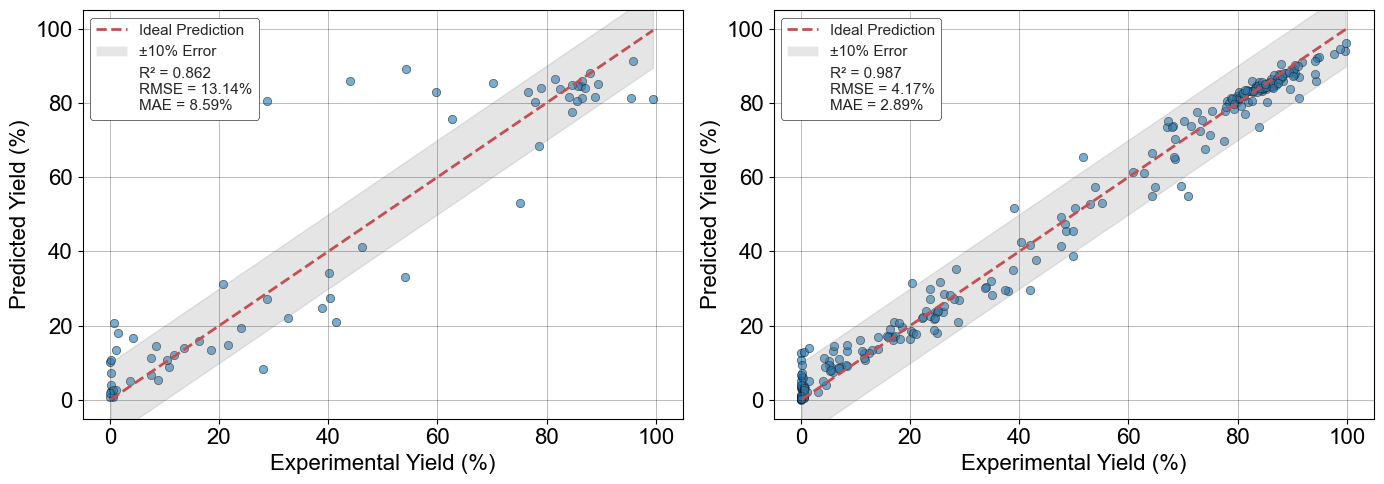

Training for fold 1/5
Test  R² = 0.838  |  MAE = 9.20%  |  RMSE = 13.61%
Train R² = 0.986  |  MAE = 3.06%  |  RMSE = 4.30%


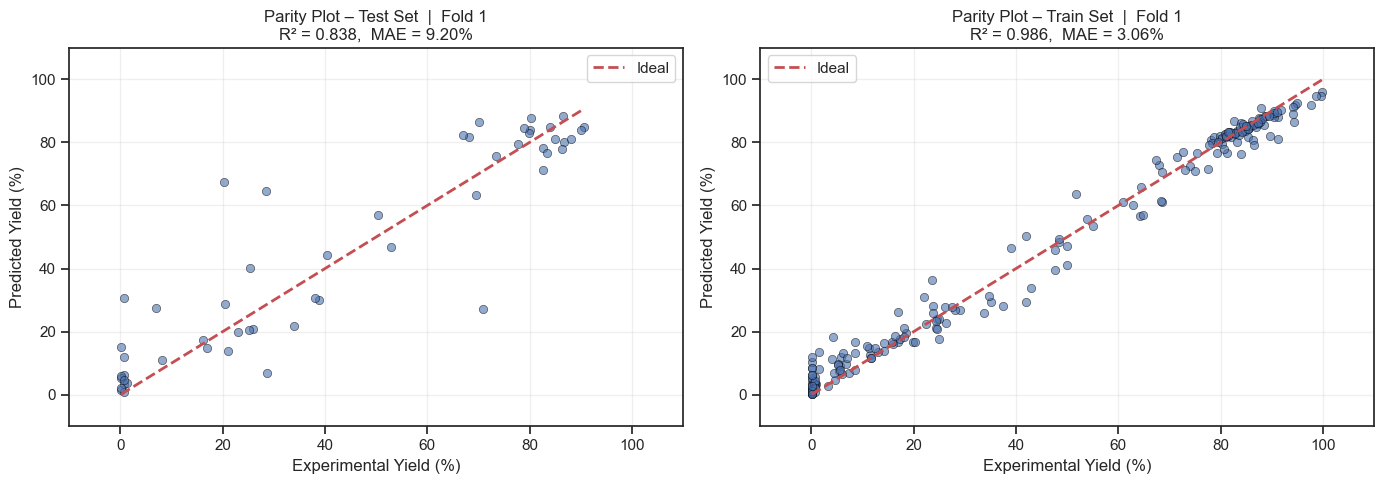

Training for fold 2/5
Test  R² = 0.931  |  MAE = 6.67%  |  RMSE = 9.85%
Train R² = 0.982  |  MAE = 3.39%  |  RMSE = 4.71%


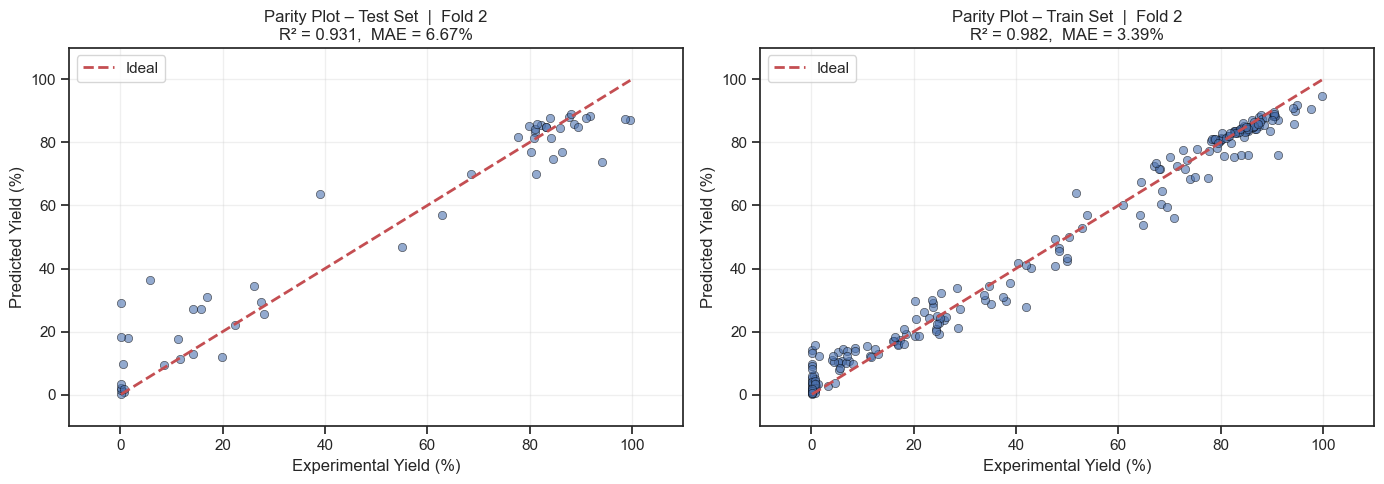

Training for fold 3/5
Test  R² = 0.898  |  MAE = 8.93%  |  RMSE = 11.81%
Train R² = 0.983  |  MAE = 3.18%  |  RMSE = 4.67%


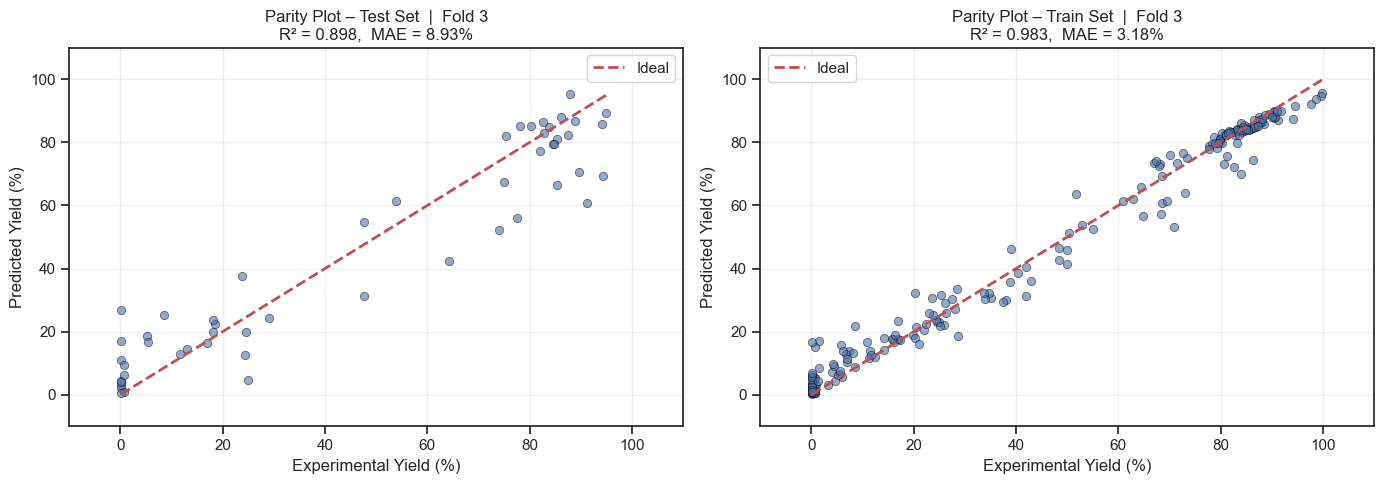

Training for fold 4/5
Test  R² = 0.861  |  MAE = 8.82%  |  RMSE = 13.39%
Train R² = 0.985  |  MAE = 3.00%  |  RMSE = 4.39%


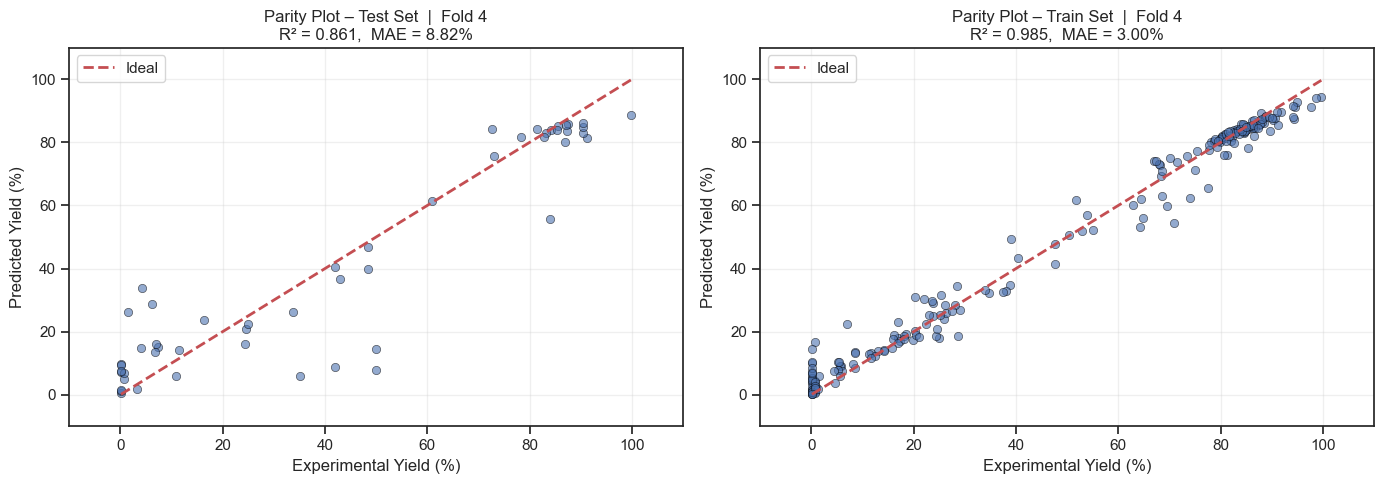

Training for fold 5/5
Test  R² = 0.909  |  MAE = 7.96%  |  RMSE = 10.64%
Train R² = 0.985  |  MAE = 3.09%  |  RMSE = 4.45%


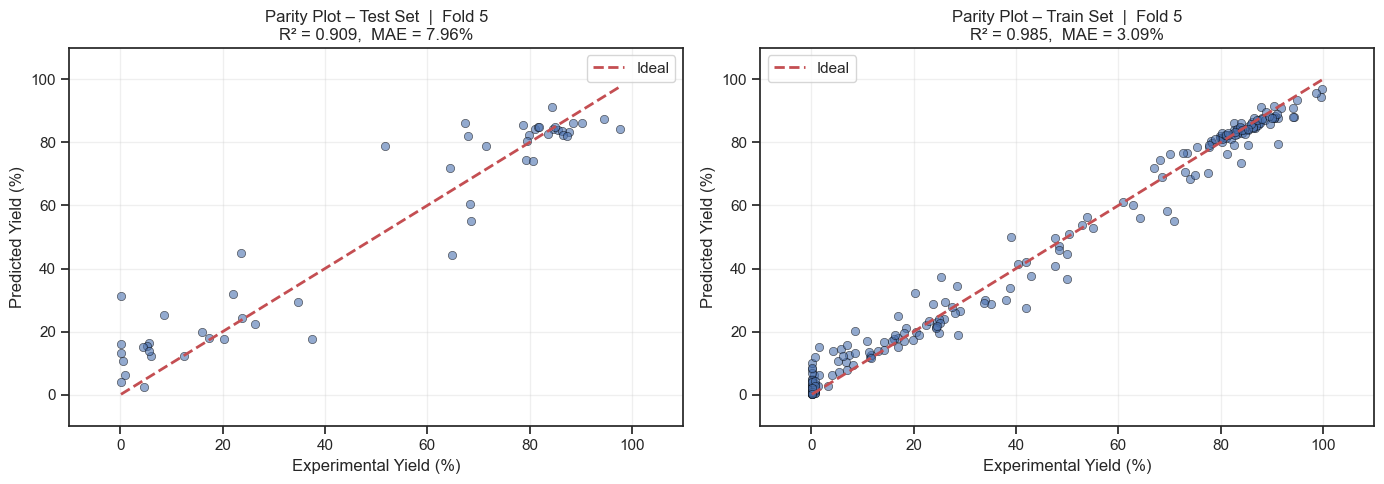


Cross-validation results testing:
MAE: 8.32% ± 0.92%
R²:  0.887 ± 0.03344
RMSE: 11.86% ± 1.48%

Cross-validation results training:
MAE: 3.14% ± 0.14%
R²:  0.984 ± 0.00138
RMSE: 4.50% ± 0.16%


In [17]:
# Making the model
rf_best_model = RandomForestRegressor(random_state=random_number_seed, **study.best_params, n_jobs=-1)

rf_best_model.fit(X_train, Y_train)

# Calculating the target
Y_train_rf_best_model_pred = rf_best_model.predict(X_train)
Y_test_rf_best_model_pred  = rf_best_model.predict(X_test)

# Metrics and plotting
performance_metrics(Y_train, Y_train_rf_best_model_pred, Y_test, Y_test_rf_best_model_pred)
parity_plot(Y_train, Y_train_rf_best_model_pred, Y_test, Y_test_rf_best_model_pred)

# Run cross validation on final model
r2_per_fold_test_rf, r2_per_fold_train_rf, mae_per_fold_test_rf, mae_per_fold_train_rf, rmse_per_fold_test_rf, rmse_per_fold_train_rf = run_cross_validation_rf(X_train, Y_train, params=study.best_params, n_splits=5)

# Summary
print(f'\nCross-validation results testing:')
print(f'MAE: {np.mean(mae_per_fold_test_rf):.2f}% ± {np.std(mae_per_fold_test_rf):.2f}%')
print(f'R²:  {np.mean(r2_per_fold_test_rf):.3f} ± {np.std(r2_per_fold_test_rf):.5f}')
print(f'RMSE: {np.mean(rmse_per_fold_test_rf):.2f}% ± {np.std(rmse_per_fold_test_rf):.2f}%')

print(f'\nCross-validation results training:')
print(f'MAE: {np.mean(mae_per_fold_train_rf):.2f}% ± {np.std(mae_per_fold_train_rf):.2f}%')
print(f'R²:  {np.mean(r2_per_fold_train_rf):.3f} ± {np.std(r2_per_fold_train_rf):.5f}')
print(f'RMSE: {np.mean(rmse_per_fold_train_rf):.2f}% ± {np.std(rmse_per_fold_train_rf):.2f}%')

In [ ]:
feature_importance(rf_best_model)

#### SHAP-analysis of the Optuna best model

In [ ]:
background = X_train
explainer = shap.TreeExplainer(rf_best_model, background)
shap_values_raw = explainer.shap_values(X_test)

# Handle both old SHAP (returns list) and new SHAP (returns array directly)
if isinstance(shap_values_raw, list):
    shap_vals = shap_values_raw[0]   # old: list of arrays, one per output
else:
    shap_vals = shap_values_raw      # new: array directly, shape (n_samples, n_features)

# Squeeze in case of shape (n_samples, n_features, 1)
if shap_vals.ndim == 3:
    shap_vals = shap_vals[:, :, 0]

print(f"SHAP values shape: {shap_vals.shape}")         # should be (n_test, n_features)
print(f"X_test_processed shape: {X_test_processed.shape}")  # should match

In [ ]:
shap.summary_plot(shap_vals, X_test, feature_names=feature_names, plot_type='bar', show=True)

In [ ]:
# Beeswarm plot
shap.summary_plot(shap_vals, X_test, feature_names=feature_names, show=True)

In [ ]:
# Tabular ranking
shap_importance = pd.DataFrame({
    'descriptor': feature_names,
    'mean_abs_shap': np.abs(shap_vals).mean(axis=0)
}).sort_values('mean_abs_shap', ascending=False)

print(shap_importance)

##### Outlier analysation

In [ ]:
results_check = pd.DataFrame({
    'y_true': Y_test,
    'y_pred': Y_test_best_nn_pred,
    'residual': Y_test - Y_test_best_nn_pred,
    'abs_residual': np.abs(Y_test - Y_test_best_nn_pred),
    'ligand' : df_remaining['catalyst'],
    'time': df_remaining['time_s'],
    'temperautre': df_remaining['temp_c'],
    'cat loading': df_remaining['cat_loading'],
    'aryl halide': df_remaining['name_aryl_halide'],
    'boron species': df_remaining['name_boron_species']
}, index=X_test.index)

# Find outliers
outliers = results_check.nlargest(10, 'abs_residual')
# # Look them up in the orginal dataframe
# original_df.loc[outliers.index]

In [ ]:
import plotly.express as px
results_check['original_index'] = results_check.index
fig = px.scatter(results_check, x='y_true', y='y_pred', hover_data=['original_index', 'residual'], title='Predicted vs Actual Yields with Residuals')
fig.add_shape(type='line', x0=0, y0=0, x1=100, y1=100, line=dict(color='Red', dash='dash'))
fig.show()

print(outliers)

##### Extrapolatability test Perera

KRAKEN database dictionary: {'CC(C)c1cc(C(C)C)c(-c2ccccc2P(C2CCCCC2)C2CCCCC2)c(C(C)C)c1': {'sphericity_boltz': 0.704737109, 'vbur_vbur_boltz': 105.5662868, 'sterimol_burB5_boltz': 7.439480407, 'fmo_eta_boltz': 0.193131047, 'fmo_omega_boltz': 0.03833597, 'fukui_m_boltz': 0.363743942999999}, 'COc1cccc(OC)c1-c1ccccc1P(C1CCCCC1)C1CCCCC1': {'sphericity_boltz': 0.732618381, 'vbur_vbur_boltz': 101.0938553, 'sterimol_burB5_boltz': 7.15627618299999, 'fmo_eta_boltz': 0.196400018999999, 'fmo_omega_boltz': 0.033749737, 'fukui_m_boltz': 0.355754061}, 'CC(C)(C)P(C(C)(C)C)C(C)(C)C': {'sphericity_boltz': 0.889512, 'vbur_vbur_boltz': 65.12848283, 'sterimol_burB5_boltz': 4.894739112, 'fmo_eta_boltz': 0.25289, 'fmo_omega_boltz': 0.016170053, 'fukui_m_boltz': 0.63368}, 'CCCCP(C12CC3CC(CC(C3)C1)C2)C12CC3CC(CC(C3)C1)C2': {'sphericity_boltz': 0.781771957, 'vbur_vbur_boltz': 64.29165019, 'sterimol_burB5_boltz': 6.61531294399999, 'fmo_eta_boltz': 0.237805293999999, 'fmo_omega_boltz': 0.0202438089999999, 'fukui

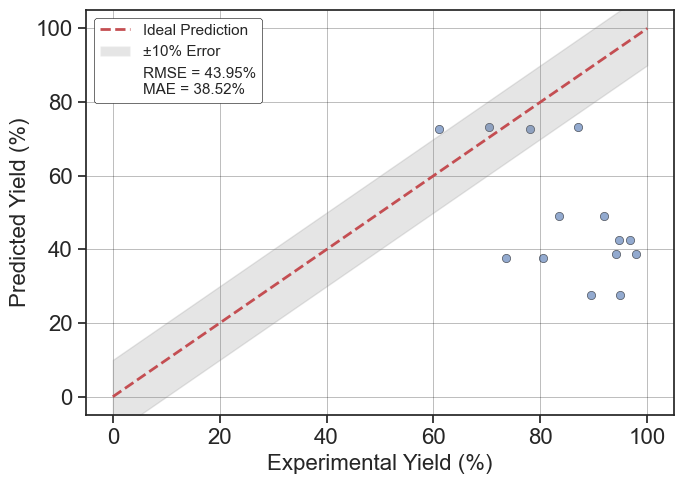

In [ ]:
# Loading the Perera dataset
path_perera_dataset = r"Perera_database - COMPLETE - BASELINE.xlsx"
df_perera = pd.read_excel(path_perera_dataset)

# Selecting specific data that matches the Reizman dataset.
df_perera = df_perera[df_perera['name_solvent'] == 'THF']
# df_perera = df_perera[df_perera['catalyst'].isin(['XPhos', 'SPhos', 'P(Cy)3', 'P(Ph)3', 'P(tBu)3'])]
df_perera = df_perera[df_perera['name_base'].isin(['Et3N'])] # NaOH very similar, KOH also pretty okay

# Adding the ligand descriptors from the KRAKEN
# Call the function with chosen ligand descriptors
append_ligand_descriptors(df_perera, df_kraken, selected_ligand_descriptor_list)

# Selecting the aryl and boron descriptors
selected_aryl_boron_descriptors = select_aryl_boron_solvent_descriptors(df_perera, selected_aryl_descriptor_list, selected_boron_descriptor_list, selected_solvent_descriptor_list)

# Delete the datapoints where there is a missing value for either ligands or base, because the model cannot learn from missing values and there are only a few datapoints with missing values.
df_perera_remaining = df_perera.dropna(subset=['ligand_smiles', 'smiles_base'])

# Check how much was removed
original_count = len(df_perera)
remaining_count = len(df_perera_remaining)
removed_count = original_count - remaining_count
removed_percent = (removed_count / original_count) * 100

print(f"Original rows: {original_count}")
print(f"Rows after removal: {remaining_count}")
print(f"Removed rows: {removed_count} ({removed_percent:.1f}%)")
print(f"Removed {removed_percent:.1f}% of data")

# Seperation of features (inputs) and targets (outputs) of the model
X_perera = df_perera_remaining.drop(['yield_pct', 'ligand_smiles', 'catalyst',
                       'name_aryl_halide', 'smiles_aryl_halide', 'name_boron_species',
                      'smiles_boron_species', 'name_base', 'smiles_base', 'name_solvent',
                       'smiles_solvent', 'number_reaction', 'precatalyst'], axis = 1)
Y_perera = df_perera_remaining['yield_pct'].values

# Checking the shape
print(f"\nProcessed feature matrix shape: {X_perera.shape}")

# Now predict the Perera dataset with the best RF model trained on the Reizman dataset
Y_perera_pred = rf_best_model.predict(X_perera)

# Evaluate performance on the Perera dataset
performance_metrics(Y_perera, Y_perera_pred, Y_perera, Y_perera_pred)

# Plot the results
parity_plot_single(Y_perera, Y_perera_pred)